<a href="https://colab.research.google.com/github/mughesaraja/Olist-Ecommerce-Marketing-Analytics/blob/main/retail_demand_forecasting_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

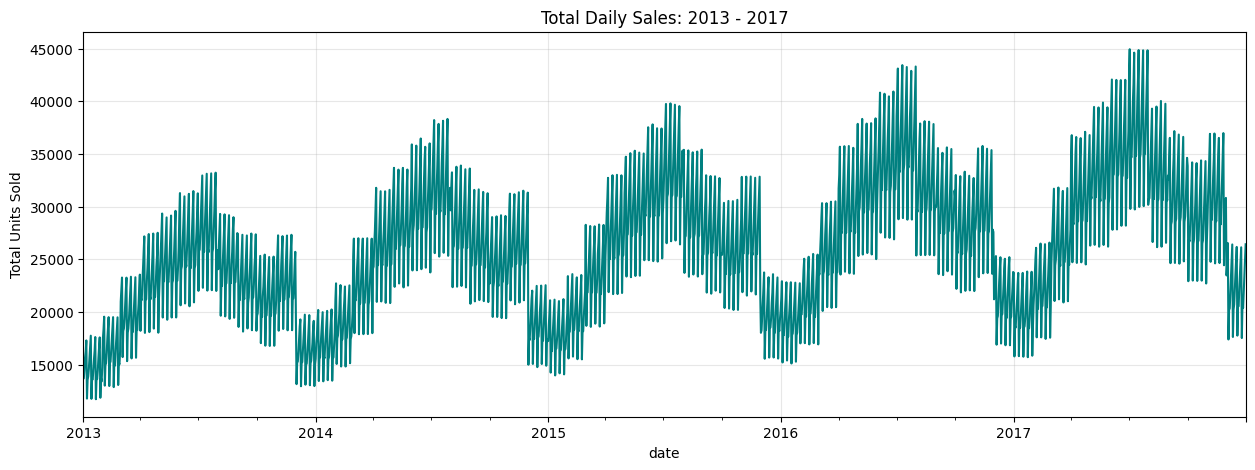

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the training data
train = pd.read_csv('train.csv')

# 2. Fix the date column
train['date'] = pd.to_datetime(train['date'])

# 3. Aggregate to see TOTAL sales across all stores/items
# This turns 913k rows into 1,826 days
daily_total = train.groupby('date')['sales'].sum()

# 4. Plot it
plt.figure(figsize=(15, 5))
daily_total.plot(color='teal')
plt.title('Total Daily Sales: 2013 - 2017')
plt.ylabel('Total Units Sold')
plt.grid(True, alpha=0.3)
plt.show()

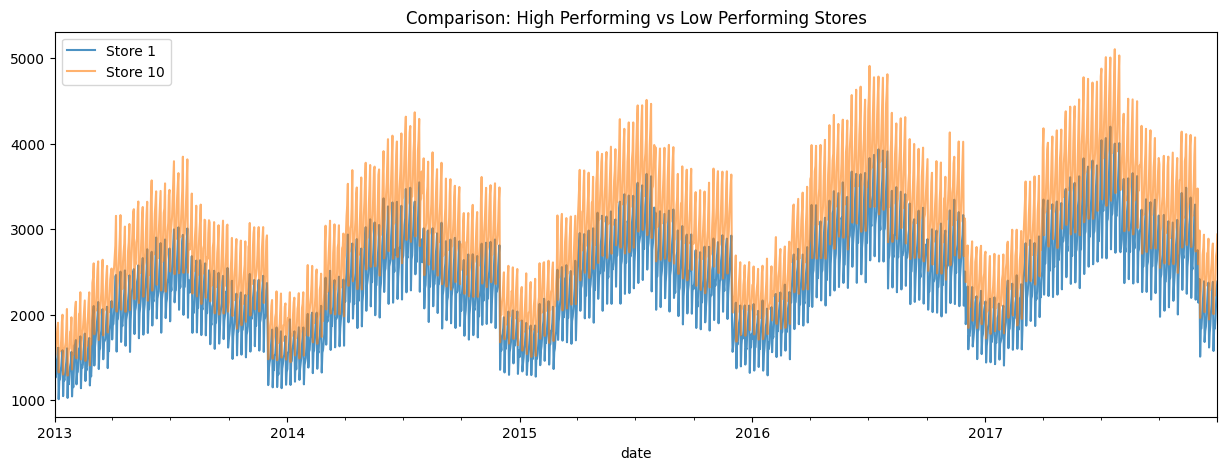

In [3]:
# Filter for just Store 1 and Store 10 to compare performance
s1 = train[train['store'] == 1].groupby('date')['sales'].sum()
s10 = train[train['store'] == 10].groupby('date')['sales'].sum()

plt.figure(figsize=(15, 5))
s1.plot(label='Store 1', alpha=0.8)
s10.plot(label='Store 10', alpha=0.6)
plt.title('Comparison: High Performing vs Low Performing Stores')
plt.legend()
plt.show()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


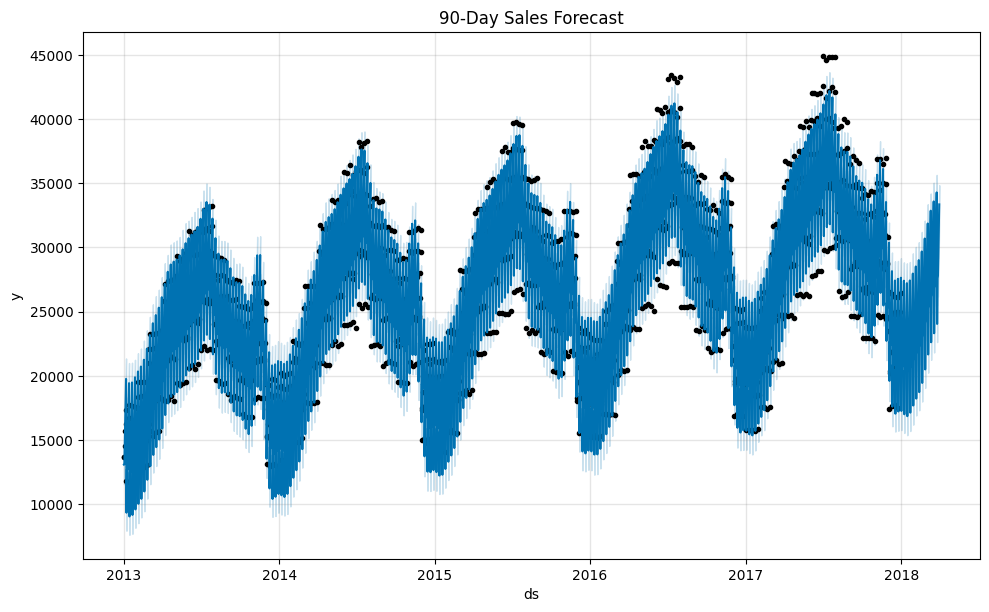

In [4]:
from prophet import Prophet

# 1. Prophet requires specific column names: 'ds' for date and 'y' for value
df_prophet = daily_total.reset_index()
df_prophet.columns = ['ds', 'y']

# 2. Initialize and fit the model
# We include yearly and weekly seasonality because we saw them in your graph!
model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
model.fit(df_prophet)

# 3. Create a future dataframe for the next 90 days
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

# 4. Plot the results
fig1 = model.plot(forecast)
plt.title('90-Day Sales Forecast')
plt.show()

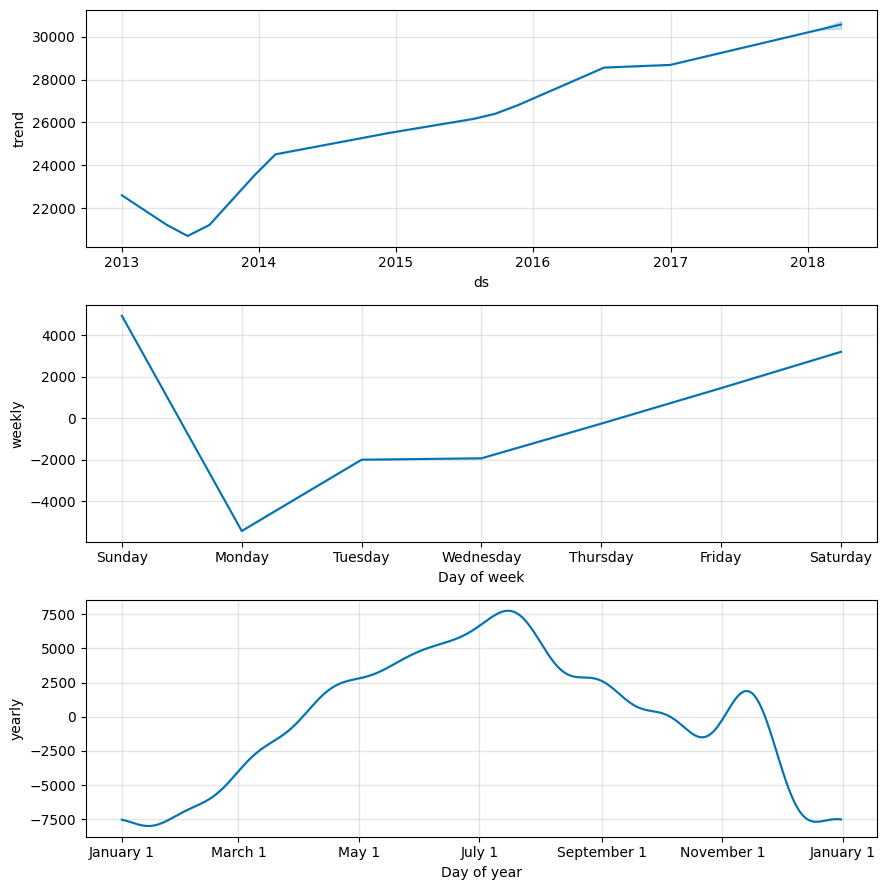

In [5]:
# This breaks the forecast into Trend, Weekly, and Yearly patterns
model.plot_components(forecast)
plt.show()

In [6]:
from prophet.diagnostics import cross_validation, performance_metrics

# 1. This 'cuts' the data and tests the model on hidden slices of the past
df_cv = cross_validation(model, initial='730 days', period='180 days', horizon='90 days')

# 2. Calculate metrics
df_p = performance_metrics(df_cv)
print(f"Your Average MAPE is: {df_p['mape'].mean():.2%}")

INFO:prophet:Making 6 forecasts with cutoffs between 2015-04-16 00:00:00 and 2017-10-02 00:00:00


  0%|          | 0/6 [00:00<?, ?it/s]

Your Average MAPE is: 4.39%
